In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from lightgbm import LGBMRegressor
import seaborn as sns

In [2]:
df=pd.read_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv')

In [3]:
bad_status = [
    'Cancelled',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Damaged',
    'Shipped - Lost in Transit'
]

df = df[~df['Status'].isin(bad_status)]

In [4]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,SKU_freq,year,month,day,Amount_missing,weekday,is_weekend,Amount_log,ship_city_grouped,ship_city_grouped_freq
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,...,108,2022,4,30,0,5,1,6.008813,BENGALURU,10666
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,...,14,2022,4,30,0,5,1,5.799093,NAVI MUMBAI,1254
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,...,17,2022,4,30,0,5,1,6.354370,CHENNAI,5226
5,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET264-KR-NP-XL,Set,XL,Shipped,1,...,136,2022,4,30,0,5,1,6.715383,GHAZIABAD,1301
6,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0095-SET-L,Set,L,Shipped,1,...,75,2022,4,30,0,5,1,6.483107,Other,70164


In [5]:
df["B2B_category_freq"] = df.groupby(["B2B", "Category"])["Category"].transform("count")
df["B2B_fulfilment_freq"] = df.groupby(["B2B", "Fulfilment"])["Fulfilment"].transform("count")


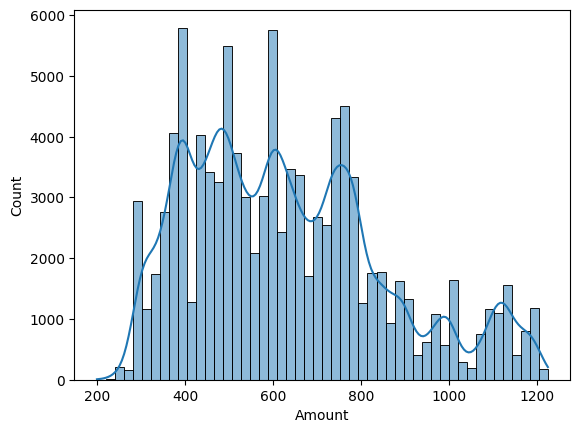

In [6]:
sns.histplot(df["Amount"], bins=50, kde=True)
plt.show()

In [7]:
# 1) SKU frequency
df['SKU_freq'] = df['SKU'].map(df['SKU'].value_counts())

# 2) Extract SKU parts
df['sku_type'] = df['SKU'].str.split('-').str[1]
df['sku_size'] = df['SKU'].str.split('-').str[-1]

In [8]:
# Drop raw SKU after extracting useful features
df.drop(columns=['SKU','Amount_missing','Amount_log','year'], inplace=True)

In [9]:
cat_cols = ['Category', 'Size', 'Fulfilment', 'ship-state', 'sku_type', 'sku_size']
num_cols = ['Qty', 'month', 'SKU_freq','weekday','is_weekend']


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
            ]),
            cat_cols
        )
    ]
)

In [11]:
X = df.drop('Amount', axis=1)
y = df['Amount']


In [12]:
y = np.log1p(df['Amount'])

 # CatBoost MODEL 

In [13]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

pip = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(
        iterations=1000,
        depth=8,
        learning_rate=0.03,
        loss_function='RMSE',
        verbose=0,
        random_state=42,
        allow_writing_files=False
    ))
])

In [14]:
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pip,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

fold_results = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Train_MAE': -cv_results['train_mae'],
    'Test_MAE': -cv_results['test_mae'],
    'Train_RMSE': -cv_results['train_rmse'],
    'Test_RMSE': -cv_results['test_rmse'],
    'Train_R2': cv_results['train_r2'],
    'Test_R2': cv_results['test_r2']
})

print(fold_results)

   Fold  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE  Train_R2   Test_R2
0     1   0.169711  0.171284    0.220583   0.221584  0.609183  0.613201
1     2   0.170025  0.170370    0.220712   0.221383  0.609691  0.610109
2     3   0.169812  0.171146    0.220660   0.221616  0.611623  0.602205
3     4   0.169750  0.171371    0.220403   0.222861  0.612273  0.598766
4     5   0.169699  0.171014    0.220247   0.223232  0.611857  0.601428


In [44]:
pred = cross_val_predict(pip, X, y, cv=cv, n_jobs=-1)

In [45]:
y_actual = np.expm1(y)
pred_actual = np.expm1(pred)

mae = mean_absolute_error(y_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
r2 = r2_score(y_actual, pred_actual)

print("OOF MAE:", mae)
print("OOF RMSE:", rmse)
print("OOF R2:", r2)

OOF MAE: 117.62785639130237
OOF RMSE: 170.62800957306288
OOF R2: 0.5913293971018468


In [15]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pip,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

In [17]:
from sklearn.model_selection import RandomizedSearchCV, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'model__iterations': [300, 500, 700, 1000],
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__subsample': [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    estimator=pip,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("Best Params:", search.best_params_)
print("Best CV Score:", search.best_score_)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'model__subsample': 0.8, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 9, 'model__iterations': 500, 'model__depth': 6}
Best CV Score: 0.5801561471912654


 # XGBOOST Model

In [46]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgb_pip = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

In [47]:
cv_results_XG = cross_validate(
    xgb_pip,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

In [48]:
fold_results = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Train_MAE': -cv_results_XG['train_mae'],
    'Test_MAE': -cv_results_XG['test_mae'],
    'Train_RMSE': -cv_results_XG['train_rmse'],
    'Test_RMSE': -cv_results_XG['test_rmse'],
    'Train_R2': cv_results_XG['train_r2'],
    'Test_R2': cv_results_XG['test_r2']
})

print(fold_results)

   Fold  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE  Train_R2   Test_R2
0     1   0.177642  0.180648    0.251971   0.252914  0.596596  0.591896
1     2   0.177139  0.182119    0.246714   0.271179  0.609749  0.547149
2     3   0.177612  0.180427    0.251362   0.252685  0.599989  0.586610
3     4   0.177091  0.182938    0.250237   0.257489  0.601731  0.578679
4     5   0.177047  0.183054    0.250724   0.260559  0.601478  0.562890


In [49]:
df['Status'].value_counts()

Status
Shipped                          76576
Shipped - Delivered to Buyer     28529
Shipped - Picked Up                970
Pending                            646
Pending - Waiting for Pick Up      277
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Name: count, dtype: int64

In [50]:
status_map = {
    "Shipped": "Shipped",
    "Shipped - Delivered to Buyer": "Delivered",
    "Shipped - Picked Up": "In_Transit",
    "Pending": "Pending",
    "Pending - Waiting for Pick Up": "Pending",
    "Shipped - Out for Delivery": "In_Transit",
    "Shipped - Rejected by Buyer": "Other",
    "Shipping": "In_Transit"
}

df["Status_grouped"] = df["Status"].map(status_map).fillna("Other")

In [53]:
df["Status_grouped"].value_counts()

Status_grouped
Shipped       76576
Delivered     28529
In_Transit     1013
Pending         923
Other            11
Name: count, dtype: int64

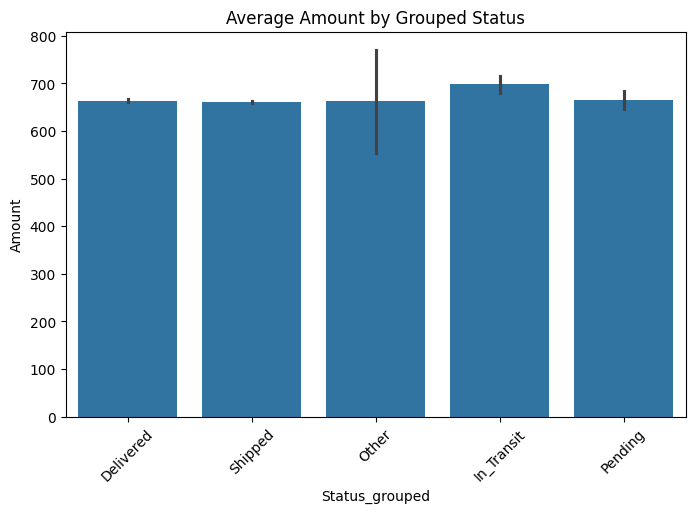

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Status_grouped", y="Amount")
plt.title("Average Amount by Grouped Status")
plt.xticks(rotation=45)
plt.show()

In [66]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

lgbm_pip = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    ))
])

In [68]:
cv_results_LGBM = cross_validate(
    lgbm_pip,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 192
[LightGBM] [Info] Number of data points in the train set: 85642, number of used features: 96
[LightGBM] [Info] Start training from score 6.419390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 190
[LightGBM] [Info] Number of data points in the train set: 85642, number of used features: 95
[LightGBM] [Info] Start training from score 6.420344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [37]:
model.fit(X, y, cat_features=cat_cols)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

importance_df.head(20)

NameError: name 'model' is not defined

In [39]:
target_corr = corr_matrix["Amount"].sort_values(ascending=False)
print(target_corr)

Amount        1.000000
Qty           0.108103
month         0.057106
SKU_freq      0.056068
day           0.013712
is_weekend    0.003409
weekday       0.002596
year               NaN
Name: Amount, dtype: float64


In [40]:
analysis_df = X.copy()
analysis_df["actual"] = np.expm1(y)
analysis_df["pred"] = np.expm1(pred)
analysis_df["error"] = analysis_df["actual"] - analysis_df["pred"]
analysis_df["abs_error"] = analysis_df["error"].abs()

<Axes: xlabel='actual', ylabel='pred'>

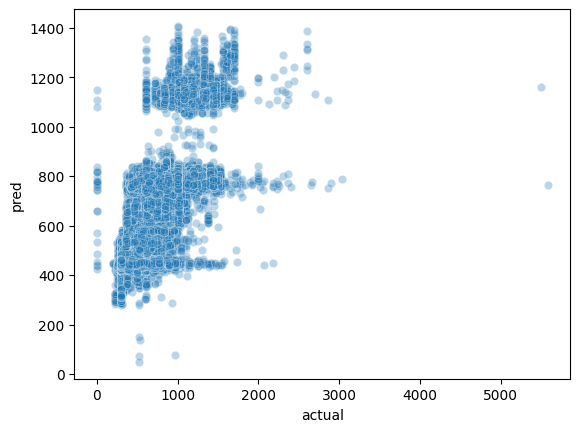

In [41]:
sns.scatterplot(data=analysis_df, x="actual", y="pred", alpha=0.3)